In [ ]:
# ===============================================
# STEP 0: Install required packages (run once)
# ===============================================
!pip install librosa soundfile tqdm tensorflow==2.12.0 --quiet


ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.12.0


In [ ]:
# ===============================================
# STEP 1: Imports & mount Drive
# ===============================================
import os
import zipfile
from glob import glob
from tqdm import tqdm
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ===============================================
# STEP 2: Unzip / point to your TESS dataset
# ===============================================
# Replace with path to the ZIP you shared (or to the extracted folder)
DRIVE_ZIP = "/content/drive/MyDrive/ML-datasets/TESS.zip"   # <-- CHANGE if needed
EXTRACTED_DIR = "/content/tess_data"

# If you already uploaded the extracted folder, you can set EXTRACTED_DIR directly
if not os.path.exists(EXTRACTED_DIR):
    os.makedirs(EXTRACTED_DIR)
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
        z.extractall(EXTRACTED_DIR)
    print("Unzipped to:", EXTRACTED_DIR)
else:
    print("Using existing folder:", EXTRACTED_DIR)

# Print a few files
for root, dirs, files in os.walk(EXTRACTED_DIR):
    if files:
        print("Sample folder:", root, "has", len([f for f in files if f.endswith('.wav')]), "wav files")
    break


Unzipped to: /content/tess_data


In [ ]:
# ===============================================
# STEP 3: Collect file paths and labels
# ===============================================
# TESS usually organizes files in folders where folder or filename includes emotions.
# We'll collect all .wav files recursively and derive the label from the filename or parent folder.

wav_files = glob(os.path.join(EXTRACTED_DIR, '**', '*.wav'), recursive=True)
len(wav_files)


5600

In [ ]:
# Helper: infer label from path/filename
import re
def extract_label(path):
    # common emotion tokens in TESS (adjust if needed)
    tokens = ['anger', 'angry', 'happy', 'sad', 'surprise', 'fear', 'disgust', 'neutral', 'calm']
    # lower path
    l = path.lower()
    # check folder names
    parts = l.replace('\\','/').split('/')
    for p in reversed(parts):
        for t in tokens:
            if t in p:
                return t
    # fallback: look in filename
    fname = os.path.basename(l)
    for t in tokens:
        if t in fname:
            return t
    # last resort: unknown
    return 'unknown'

# Show a few examples
examples = wav_files[:10]
[(os.path.basename(p), extract_label(p)) for p in examples]


[('YAF_puff_fear.wav', 'fear'),
 ('YAF_pike_fear.wav', 'fear'),
 ('YAF_witch_fear.wav', 'fear'),
 ('YAF_which_fear.wav', 'fear'),
 ('YAF_search_fear.wav', 'fear'),
 ('YAF_pool_fear.wav', 'fear'),
 ('YAF_tool_fear.wav', 'fear'),
 ('YAF_bar_fear.wav', 'fear'),
 ('YAF_food_fear.wav', 'fear'),
 ('YAF_far_fear.wav', 'fear')]

In [ ]:
# ===============================================
# STEP 4: Feature extraction - MFCC (with padding)
# ===============================================
# Parameters
SR = 22050            # sampling rate
DURATION = 3.0        # max duration to load (seconds)
SAMPLES = int(SR * DURATION)
N_MFCC = 40
MAX_PAD_LEN = 174     # number of time steps for MFCC — chosen empirically (you can adjust)

def extract_mfcc(file_path, sr=SR, n_mfcc=N_MFCC, max_pad_len=MAX_PAD_LEN):
    # load audio (mono)
    y, _ = librosa.load(file_path, sr=sr, duration=DURATION)
    # pad or truncate to SAMPLES
    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)), 'constant')
    else:
        y = y[:SAMPLES]
    # compute MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # mfcc shape (n_mfcc, time). pad time axis if needed
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc

# Build dataset (this can take several minutes)
X = []
y = []
filepaths = []
for fp in tqdm(wav_files):
    lbl = extract_label(fp)
    if lbl == 'unknown':
        continue
    try:
        mf = extract_mfcc(fp)
        X.append(mf)
        y.append(lbl)
        filepaths.append(fp)
    except Exception as e:
        # skip unreadable file
        print("Error on", fp, e)

X = np.array(X)   # shape (n_samples, n_mfcc, max_pad_len)
y = np.array(y)
print("Feature array shape:", X.shape)
print("Labels shape:", y.shape)


100%|██████████| 5600/5600 [02:21<00:00, 39.71it/s]


Feature array shape: (5600, 40, 174)
Labels shape: (5600,)


In [ ]:
# ===============================================
# STEP 5: Encode labels and prepare for models
# ===============================================
le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)
print("Classes:", le.classes_)

# For CNN we need channels last: (samples, n_mfcc, time, 1)
X_cnn = X[..., np.newaxis]

# For LSTM/RNN we will use (samples, time, features) -> transpose to (samples, time, n_mfcc)
X_lstm = np.transpose(X, (0, 2, 1))   # shape (n_samples, time_steps, n_mfcc)

# Train-test split
Xc_train, Xc_test, y_train, y_test = train_test_split(X_cnn, y_enc, test_size=0.2, stratify=y_enc, random_state=42)
Xr_train, Xr_test, _, _ = train_test_split(X_lstm, y_enc, test_size=0.2, stratify=y_enc, random_state=42)  # same split

# One-hot targets
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("Train shapes (CNN):", Xc_train.shape, y_train_cat.shape)
print("Test shapes (CNN):", Xc_test.shape, y_test_cat.shape)
print("Train shapes (LSTM):", Xr_train.shape)


Classes: ['angry' 'calm' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
Train shapes (CNN): (4480, 40, 174, 1) (4480, 8)
Test shapes (CNN): (1120, 40, 174, 1) (1120, 8)
Train shapes (LSTM): (4480, 174, 40)


In [ ]:
# ===============================================
# STEP 6A: CNN Model (2D) on MFCC images
# ===============================================
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPool2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_input_shape = Xc_train.shape[1:]  # (n_mfcc, time, 1)
cnn_model = build_cnn(cnn_input_shape, num_classes)
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 40, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,966,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,061,960 (7.87 MB)

 Trainable params: 2,061,512 (7.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ===============================================
# STEP 6B: LSTM Model (sequence model)
# ===============================================
def build_lstm(input_shape, num_classes):
    model = models.Sequential([
        layers.Masking(mask_value=0., input_shape=input_shape),
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(64),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_input_shape = Xr_train.shape[1:]  # (time_steps, n_mfcc)
lstm_model = build_lstm(lstm_input_shape, num_classes)
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 174, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 174, 128)       │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 174, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,616 (549.28 KB)

 Trainable params: 140,616 (549.28 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===============================================
# STEP 7: Train (pick one model to run)
# ===============================================
# Set to 'cnn' or 'lstm' depending on which you want to train
MODEL_TO_TRAIN = 'cnn'   # or 'lstm'

EPOCHS = 30
BATCH_SIZE = 32

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('/content/best_audio_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]

if MODEL_TO_TRAIN == 'cnn':
    history = cnn_model.fit(
        Xc_train, y_train_cat,
        validation_data=(Xc_test, y_test_cat),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks
    )
    best_model = cnn_model
else:
    history = lstm_model.fit(
        Xr_train, y_train_cat,
        validation_data=(Xr_test, y_test_cat),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks
    )
    best_model = lstm_model


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.7450 - loss: 1.9778
Epoch 1: val_accuracy improved from -inf to 0.99375, saving model to /content/best_audio_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 92s 629ms/step - accuracy: 0.7461 - loss: 1.9681 - val_accuracy: 0.9937 - val_loss: 0.0394 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9868 - loss: 0.0686
Epoch 2: val_accuracy improved from 0.99375 to 0.99464, saving model to /content/best_audio_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 92s 660ms/step - accuracy: 0.9868 - loss: 0.0685 - val_accuracy: 0.9946 - val_loss: 0.0229 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9909 - loss: 0.0369
Epoch 3: val_accuracy improved from 0.99464 to 0.99732, saving model to /content/best_audio_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 93s 668ms/step - accuracy: 0.9909 - loss: 0.0369 - val_accuracy: 0.9973 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.9922 - loss: 0.0282
Epoch 4: val_accuracy improved from 0.99732 to 0.99821, saving model to /content/best_audio_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 136s 622ms/step - accuracy: 0.9922 - loss: 0.0282 - val_accuracy: 0.9982 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9954 - loss: 0.0151
Epoch 5: val_accuracy did not improve from 0.99821
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 620ms/step - accuracy: 0.9954 - loss: 0.0152 - val_accuracy: 0.9973 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.9948 - loss: 0.0207
Epoch 6: val_accuracy did not improve from 0.99821
140/140 ━━━━━━━━━━━━━━━━━━━━ 142s 617ms/step - accuracy: 0.9948 - loss: 0.0207 - val_accuracy: 0.9973 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.9983 - loss: 0.0071
Epoch 7: val_accuracy did not improve from 0.99821
140/140 ━━━━━━━━━━━━━━━━━━━━ 148s 664ms/step - accuracy: 0.9983 - loss: 0.0071 - val_accuracy: 0.9848 - val_loss: 0.0627 - learning_rate: 0.0010
Epo

140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 597ms/step - accuracy: 0.9917 - loss: 0.0316 - val_accuracy: 0.9991 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9955 - loss: 0.0154
Epoch 9: val_accuracy did not improve from 0.99911
140/140 ━━━━━━━━━━━━━━━━━━━━ 90s 644ms/step - accuracy: 0.9955 - loss: 0.0154 - val_accuracy: 0.9973 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 10/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9939 - loss: 0.0245
Epoch 10: val_accuracy did not improve from 0.99911
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 608ms/step - accuracy: 0.9939 - loss: 0.0245 - val_accuracy: 0.9955 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 11/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9951 - loss: 0.0113
Epoch 11: val_accuracy improved from 0.99911 to 1.00000, saving model to /content/best_audio_model.h5


140/140 ━━━━━━━━━━━━━━━━━━━━ 143s 617ms/step - accuracy: 0.9951 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 3.3217e-04 - learning_rate: 0.0010
Epoch 12/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.9965 - loss: 0.0097
Epoch 12: val_accuracy did not improve from 1.00000
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 631ms/step - accuracy: 0.9965 - loss: 0.0097 - val_accuracy: 0.9991 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 13/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9982 - loss: 0.0041
Epoch 13: val_accuracy did not improve from 1.00000
140/140 ━━━━━━━━━━━━━━━━━━━━ 139s 610ms/step - accuracy: 0.9982 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 14/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9978 - loss: 0.0053
Epoch 14: val_accuracy did not improve from 1.00000
140/140 ━━━━━━━━━━━━━━━━━━━━ 86s 612ms/step - accuracy: 0.9978 - loss: 0.0054 - val_accuracy: 0.9991 - val_loss: 0.0013 - learning_rate: 0

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       angry       1.00      1.00      1.00       160
        calm       1.00      1.00      1.00         1
     disgust       1.00      1.00      1.00       160
        fear       1.00      1.00      1.00       160
       happy       1.00      1.00      1.00       160
     neutral       1.00      1.00      1.00       160
         sad       1.00      1.00      1.00       160
    surprise       1.00      1.00      1.00       159

    accuracy                           1.00      1120
   macro avg       1.00      1.00      1.00      1120
weighted avg       1.00      1.00      1.00      1120



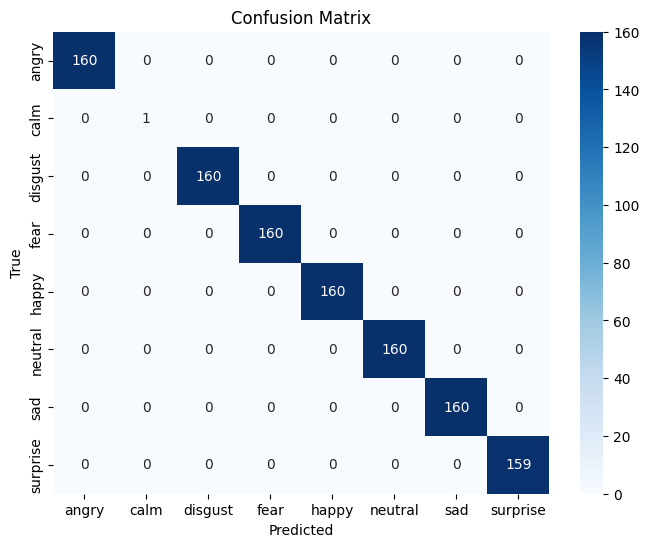

In [ ]:
# ===============================================
# STEP 8: Evaluate on Test Set
# ===============================================
# Load best saved model (optional)
# from tensorflow.keras.models import load_model
# best_model = load_model('/content/best_audio_model.h5')

if MODEL_TO_TRAIN == 'cnn':
    X_test_in = Xc_test
else:
    X_test_in = Xr_test

y_pred_prob = best_model.predict(X_test_in)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


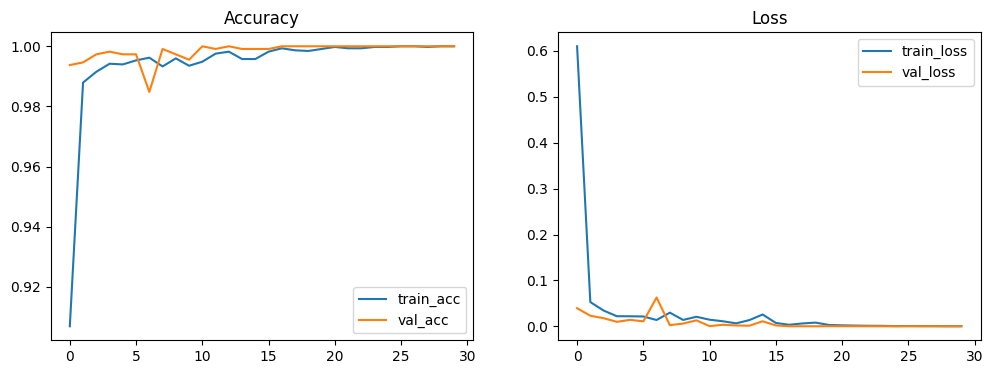

In [ ]:
# ===============================================
# STEP 9: Plot training history (accuracy & loss)
# ===============================================
def plot_history(h):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['accuracy'], label='train_acc')
    plt.plot(h.history['val_accuracy'], label='val_acc')
    plt.legend(); plt.title('Accuracy')

    plt.subplot(1,2,2)
    plt.plot(h.history['loss'], label='train_loss')
    plt.plot(h.history['val_loss'], label='val_loss')
    plt.legend(); plt.title('Loss')

plot_history(history)


In [ ]:
# ===============================================
# STEP 10: Save label encoder and model mapping
# ===============================================
import joblib
joblib.dump(le, '/content/label_encoder.pkl')
best_model.save('/content/final_emotion_model.h5')
print("Saved model and label encoder.")


Saved model and label encoder.
